# Phase 3: Behaviour Feature Engineering for AML Fraud Detection

This notebook builds account-level behavioural features from transaction logs for AML detection.

Feature groups in this notebook:
1. **Rhythm features** (how regularly transactions occur)
2. **Volatility features** (how stable/unstable amounts are)
3. **Session features** (activity concentration and session behaviour)
4. **Money-flow features** (in/out flow structure and counterparty patterns)

The output is a clean feature table saved to `../data/aml_behavior_features.csv` for downstream modeling.

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
%matplotlib inline

## Step 1 — Load AML transaction data

We load the synthetic transaction log generated earlier and validate key fields needed for feature engineering.

In [2]:
DATA_DIR = os.path.join('..', 'data')
TX_FILE = os.path.join(DATA_DIR, 'aml_synthetic_data.csv')

if not os.path.exists(TX_FILE):
    raise FileNotFoundError(f'Missing transaction file: {TX_FILE}')

tx_df = pd.read_csv(TX_FILE, parse_dates=['timestamp'])

print('Transaction shape:', tx_df.shape)
print('Timestamp range:', tx_df['timestamp'].min(), '->', tx_df['timestamp'].max())
print('Columns available:', sorted(tx_df.columns.tolist())[:15], '...')

required_cols = ['from_account','to_account','timestamp','amount_paid','amount_received','action_type']
missing = [c for c in required_cols if c not in tx_df.columns]
print('Missing required columns:', missing)

Transaction shape: (29513, 32)
Timestamp range: 2025-02-27 16:18:20.414639 -> 2025-03-30 14:22:41.485157
Columns available: ['action_type', 'amount', 'amount_paid', 'amount_received', 'balance_after', 'balance_before', 'bet_amount', 'bet_direction', 'channel', 'currency', 'deposit_amount', 'device', 'from_account', 'from_bank', 'game_result'] ...
Missing required columns: []


## Step 2 — Build a canonical account-event table

Each transaction is transformed into account-level events:
- **Outgoing event** for `from_account` using `amount_paid`
- **Incoming event** for `to_account` using `amount_received`

To handle mixed currencies, amounts are normalized to USD using the dataset currency fields and a fixed FX map; if currency is missing, the raw amount is used as-is.
This gives a consistent per-account timeline for behavioural features.

In [3]:
special_accounts = {'SOURCE', 'PLATFORM'}

FX_RATES = {
    "US Dollar": 1.0,        "Euro": 0.92,          "UK Pound": 0.79,
    "Swiss Franc": 0.90,     "Canadian Dollar": 1.35, "Australian Dollar": 1.53,
    "Yuan": 7.24,            "Yen": 149.5,           "Indian Rupee": 83.1,
    "Ruble": 90.0,           "Mexican Peso": 17.1,   "Brazilian Real": 4.97,
    "Saudi Riyal": 3.75,     "Shekel": 3.68,         "Bitcoin": 0.000015,
    "Swedish Krona": 10.4,
}

out_cols = [
    'transaction_id','timestamp','from_account','to_account','amount_paid',
    'session_id','payment_format','channel','action_type','money_launderer'
 ]
if 'paying_currency' in tx_df.columns:
    out_cols.append('paying_currency')

out_events = tx_df[out_cols].copy()
out_events = out_events.rename(columns={
    'from_account': 'account_id',
    'to_account': 'counterparty',
    'amount_paid': 'amount',
    'money_launderer': 'account_label',
    'paying_currency': 'amount_currency'
})
if 'amount_currency' not in out_events.columns:
    out_events['amount_currency'] = None
out_events['direction'] = 'out'

in_cols = [
    'transaction_id','timestamp','to_account','from_account','amount_received',
    'session_id','payment_format','channel','action_type','money_launderer'
 ]
if 'receiving_currency' in tx_df.columns:
    in_cols.append('receiving_currency')

in_events = tx_df[in_cols].copy()
in_events = in_events.rename(columns={
    'to_account': 'account_id',
    'from_account': 'counterparty',
    'amount_received': 'amount',
    'money_launderer': 'account_label',
    'receiving_currency': 'amount_currency'
})
if 'amount_currency' not in in_events.columns:
    in_events['amount_currency'] = None
in_events['direction'] = 'in'

account_events = pd.concat([out_events, in_events], ignore_index=True)
account_events = account_events[~account_events['account_id'].isin(special_accounts)].copy()
account_events['amount'] = pd.to_numeric(account_events['amount'], errors='coerce').fillna(0.0)
account_events['account_label'] = account_events['account_label'].fillna(False).astype(int)

fx_rate = account_events['amount_currency'].map(FX_RATES).fillna(1.0)
account_events['amount_usd'] = account_events['amount'] / fx_rate

account_events = account_events.sort_values(['account_id','timestamp']).reset_index(drop=True)

print('Account-event shape:', account_events.shape)
print('Unique accounts:', account_events['account_id'].nunique())
print(account_events[['account_id','timestamp','direction','amount','amount_currency','amount_usd','counterparty']].head())

Account-event shape: (30247, 13)
Unique accounts: 447
    account_id                  timestamp direction  amount amount_currency  \
0  NORM_A_0000 2025-02-28 11:18:21.099094        in   340.0             Yen   
1  NORM_A_0000 2025-02-28 11:18:34.543781       out    24.0            Yuan   
2  NORM_A_0000 2025-02-28 11:18:42.091909       out    27.0    Mexican Peso   
3  NORM_A_0000 2025-02-28 11:18:51.911200       out    39.0     Saudi Riyal   
4  NORM_A_0000 2025-02-28 11:19:02.932334       out    28.0     Swiss Franc   

   amount_usd counterparty  
0    2.274247       SOURCE  
1    3.314917     PLATFORM  
2    1.578947     PLATFORM  
3   10.400000     PLATFORM  
4   31.111111     PLATFORM  


## Step 3 — Rhythm features

Rhythm features capture behavioural timing patterns:
- transaction count and active days
- average and variability of inter-transaction gaps
- burstiness (gap variability / gap mean)
- night-time and weekend activity ratios

In [4]:
rh = account_events[['account_id','timestamp']].copy()
rh['day'] = rh['timestamp'].dt.date
rh['hour'] = rh['timestamp'].dt.hour
rh['is_night'] = ((rh['hour'] < 6) | (rh['hour'] >= 22)).astype(int)
rh['is_weekend'] = (rh['timestamp'].dt.dayofweek >= 5).astype(int)

rh = rh.sort_values(['account_id','timestamp'])
rh['gap_min'] = rh.groupby('account_id')['timestamp'].diff().dt.total_seconds() / 60.0

rhythm_features = rh.groupby('account_id').agg(
    tx_count=('timestamp','size'),
    active_days=('day','nunique'),
    mean_gap_min=('gap_min','mean'),
    std_gap_min=('gap_min','std'),
    night_tx_ratio=('is_night','mean'),
    weekend_tx_ratio=('is_weekend','mean')
).reset_index()

rhythm_features['burstiness_cv'] = rhythm_features['std_gap_min'] / rhythm_features['mean_gap_min'].replace(0, np.nan)
rhythm_features = rhythm_features.fillna(0)

print('Rhythm features shape:', rhythm_features.shape)
print(rhythm_features.head())

Rhythm features shape: (447, 8)
    account_id  tx_count  active_days  mean_gap_min  std_gap_min  \
0  NORM_A_0000        66            3    224.397500  1421.123476   
1  NORM_A_0001       134            5    171.448887  1137.613486   
2  NORM_A_0002        65            3    371.311263  2130.513626   
3  NORM_A_0003       126            6    229.476716  1404.513324   
4  NORM_A_0004       110            5    173.410017  1098.963170   

   night_tx_ratio  weekend_tx_ratio  burstiness_cv  
0        0.242424          0.242424       6.333063  
1        0.694030          0.395522       6.635292  
2        0.646154          0.200000       5.737810  
3        0.357143          0.523810       6.120505  
4        0.309091          0.300000       6.337368  


## Step 4 — Volatility features

Volatility features quantify amount instability per account:
- mean/median/std of transaction amount
- coefficient of variation (`std / mean`)
- percentile spread (`p95 - p05`)
- max-to-median ratio for extreme payment behaviour

In [5]:
vol = account_events[['account_id','amount_usd']].copy()
vol['amount_abs'] = vol['amount_usd'].abs()

volatility_features = vol.groupby('account_id').agg(
    amt_mean=('amount_abs','mean'),
    amt_median=('amount_abs','median'),
    amt_std=('amount_abs','std'),
    amt_max=('amount_abs','max'),
    amt_p95=('amount_abs', lambda s: np.percentile(s, 95)),
    amt_p05=('amount_abs', lambda s: np.percentile(s, 5))
).reset_index()

volatility_features['amt_cv'] = volatility_features['amt_std'] / volatility_features['amt_mean'].replace(0, np.nan)
volatility_features['amt_p95_p05_spread'] = volatility_features['amt_p95'] - volatility_features['amt_p05']
volatility_features['amt_max_to_median'] = volatility_features['amt_max'] / volatility_features['amt_median'].replace(0, np.nan)
volatility_features = volatility_features.fillna(0)

print('Volatility features shape:', volatility_features.shape)
print(volatility_features.head())

Volatility features shape: (447, 10)
    account_id       amt_mean  amt_median       amt_std       amt_max  \
0  NORM_A_0000      24.618046    3.969482  7.718258e+01  6.025333e+02   
1  NORM_A_0001  147985.231180    8.290812  5.222977e+05  2.600000e+06   
2  NORM_A_0002   55405.251751    6.793478  3.540544e+05  2.733333e+06   
3  NORM_A_0003  337056.652781    6.400000  2.505533e+06  2.753333e+07   
4  NORM_A_0004  206078.225871    9.356137  6.774333e+05  3.266667e+06   

        amt_p95   amt_p05    amt_cv  amt_p95_p05_spread  amt_max_to_median  
0  5.264516e+01  0.226867  3.135203        5.241829e+01       1.517914e+02  
1  1.572367e+06  0.221702  3.529391        1.572367e+06       3.136002e+05  
2  2.244047e+02  0.130015  6.390268        2.242747e+02       4.023467e+05  
3  7.001255e+05  0.180530  7.433567        7.001254e+05       4.302083e+06  
4  2.066667e+06  0.221111  3.287263        2.066666e+06       3.491470e+05  


## Step 5 — Session features

Session features characterize behavioural continuity within sessions:
- session count per account
- average session duration
- transactions per session (mean/max)
- counterparties per session (mean)

In [6]:
sess = account_events[['account_id','session_id','timestamp','counterparty']].copy()
sess = sess.dropna(subset=['session_id'])

session_level = sess.groupby(['account_id','session_id']).agg(
    session_start=('timestamp','min'),
    session_end=('timestamp','max'),
    tx_in_session=('timestamp','size'),
    uniq_counterparties_in_session=('counterparty','nunique')
).reset_index()

session_level['session_duration_min'] = (session_level['session_end'] - session_level['session_start']).dt.total_seconds() / 60.0

session_features = session_level.groupby('account_id').agg(
    session_count=('session_id','nunique'),
    avg_session_duration_min=('session_duration_min','mean'),
    median_tx_per_session=('tx_in_session','median'),
    max_tx_per_session=('tx_in_session','max'),
    avg_counterparties_per_session=('uniq_counterparties_in_session','mean')
).reset_index()

session_features = session_features.fillna(0)

print('Session features shape:', session_features.shape)
print(session_features.head())

Session features shape: (208, 6)
    account_id  session_count  avg_session_duration_min  \
0  NORM_A_0000              3                  4.359126   
1  NORM_A_0001              7                  2.876263   
2  NORM_A_0002              3                  4.150560   
3  NORM_A_0003              6                  3.629973   
4  NORM_A_0004              6                  3.228271   

   median_tx_per_session  max_tx_per_session  avg_counterparties_per_session  
0                   23.0                  27                        2.666667  
1                   20.0                  29                        2.000000  
2                   23.0                  29                        2.333333  
3                   20.0                  27                        2.333333  
4                   18.0                  26                        2.333333  


## Step 6 — Money-flow features

Money-flow features model directional movement and network structure:
- incoming vs outgoing amount and count
- net flow and out/in ratio
- unique incoming and outgoing counterparties
- transfer-action share

In [7]:
flow = account_events.copy()

in_flow = flow[flow['direction'] == 'in'].groupby('account_id').agg(
    in_amount_total=('amount_usd','sum'),
    in_tx_count=('transaction_id','size'),
    in_unique_counterparties=('counterparty','nunique')
).reset_index()

out_flow = flow[flow['direction'] == 'out'].groupby('account_id').agg(
    out_amount_total=('amount_usd','sum'),
    out_tx_count=('transaction_id','size'),
    out_unique_counterparties=('counterparty','nunique')
).reset_index()

money_flow_features = pd.merge(in_flow, out_flow, on='account_id', how='outer').fillna(0)
money_flow_features['net_flow'] = money_flow_features['in_amount_total'] - money_flow_features['out_amount_total']
money_flow_features['out_in_ratio'] = money_flow_features['out_amount_total'] / money_flow_features['in_amount_total'].replace(0, np.nan)
money_flow_features['tx_out_ratio'] = money_flow_features['out_tx_count'] / (money_flow_features['in_tx_count'] + money_flow_features['out_tx_count']).replace(0, np.nan)

transfer_share = flow.groupby('account_id')['action_type'].apply(lambda s: (s == 'transfer').mean()).reset_index(name='transfer_action_share')
money_flow_features = money_flow_features.merge(transfer_share, on='account_id', how='left')
money_flow_features = money_flow_features.fillna(0)

print('Money-flow features shape:', money_flow_features.shape)
print(money_flow_features.head())

Money-flow features shape: (447, 11)
    account_id  in_amount_total  in_tx_count  in_unique_counterparties  \
0  NORM_A_0000     7.929557e+02            3                         1   
1  NORM_A_0001     1.398913e+03            7                         1   
2  NORM_A_0002     3.446676e+02            3                         1   
3  NORM_A_0003     2.753446e+07            6                         1   
4  NORM_A_0004     6.857713e+02            6                         1   

   out_amount_total  out_tx_count  out_unique_counterparties      net_flow  \
0      8.318353e+02          63.0                        2.0 -3.887958e+01   
1      1.982862e+07         127.0                        1.0 -1.982722e+07   
2      3.600997e+06          62.0                        2.0 -3.600652e+06   
3      1.493467e+07         120.0                        2.0  1.259979e+07   
4      2.266792e+07         104.0                        2.0 -2.266723e+07   

   out_in_ratio  tx_out_ratio  transfer_action_sh

## Step 7 — Combine all behavioural features

We merge rhythm, volatility, session, and money-flow features into one account-level table.
We also attach an account-level label (`account_money_launderer`) for supervised training/evaluation.

In [8]:
features_df = rhythm_features.merge(volatility_features, on='account_id', how='outer')
features_df = features_df.merge(session_features, on='account_id', how='left')
features_df = features_df.merge(money_flow_features, on='account_id', how='left')
features_df = features_df.fillna(0)

label_df = account_events.groupby('account_id')['account_label'].max().reset_index()
label_df = label_df.rename(columns={'account_label':'account_money_launderer'})
features_df = features_df.merge(label_df, on='account_id', how='left')
features_df['account_money_launderer'] = features_df['account_money_launderer'].fillna(0).astype(int)

print('Final feature table shape:', features_df.shape)
print('Label distribution:')
print(features_df['account_money_launderer'].value_counts())
print('Any missing values:', int(features_df.isna().sum().sum()))
features_df.head()

Final feature table shape: (447, 33)
Label distribution:
account_money_launderer
1    297
0    150
Name: count, dtype: int64
Any missing values: 0


,account_id,tx_count,active_days,mean_gap_min,std_gap_min,night_tx_ratio,weekend_tx_ratio,burstiness_cv,amt_mean,amt_median,...,in_tx_count,in_unique_counterparties,out_amount_total,out_tx_count,out_unique_counterparties,net_flow,out_in_ratio,tx_out_ratio,transfer_action_share,account_money_launderer
0,NORM_A_0000,66,3,224.397500,1421.123476,0.242424,0.242424,6.333063,24.618046,3.969482,...,3,1,8.318353e+02,63.0,2.0,-3.887958e+01,1.049031,0.954545,0.0,0
1,NORM_A_0001,134,5,171.448887,1137.613486,0.694030,0.395522,6.635292,147985.231180,8.290812,...,7,1,1.982862e+07,127.0,1.0,-1.982722e+07,14174.307105,0.947761,0.0,0
2,NORM_A_0002,65,3,371.311263,2130.513626,0.646154,0.200000,5.737810,55405.251751,6.793478,...,3,1,3.600997e+06,62.0,2.0,-3.600652e+06,10447.738538,0.953846,0.0,0
3,NORM_A_0003,126,6,229.476716,1404.513324,0.357143,0.523810,6.120505,337056.652781,6.400000,...,6,1,1.493467e+07,120.0,2.0,1.259979e+07,0.542399,0.952381,0.0,0
4,NORM_A_0004,110,5,173.410017,1098.963170,0.309091,0.300000,6.337368,206078.225871,9.356137,...,6,1,2.266792e+07,104.0,2.0,-2.266723e+07,33054.634620,0.945455,0.0,0


## Step 8 — Sanity checks for AML use-case

These checks confirm the engineered features behave plausibly for fraud detection:
- distribution of key flow features
- top accounts by suspicious net/outgoing behaviour
- quick correlation view vs label

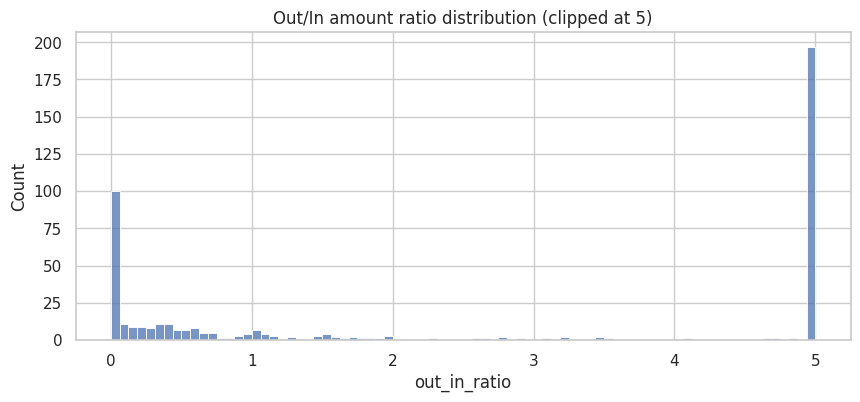

Top 10 accounts by out_amount_total:
             account_id  out_amount_total  in_amount_total      net_flow  \
178     SUSP_RAPID_0000      6.734498e+08     11192.336847 -6.734386e+08   
183     SUSP_RAPID_0005      6.336246e+08     17874.957421 -6.336067e+08   
236   TOPO_CYC_0000_N01      4.614732e+08      7000.580148 -4.614662e+08   
245   TOPO_CYC_0002_N02      4.562009e+08      4554.895889 -4.561964e+08   
195     SUSP_SPIKE_0007      4.088921e+08     22111.275432 -4.088700e+08   
240   TOPO_CYC_0001_N00      3.960801e+08      5340.848082 -3.960747e+08   
193     SUSP_SPIKE_0005      3.916763e+08      3982.012006 -3.916723e+08   
442   TOPO_STK_0004_N02      3.760667e+08       830.248538 -3.760658e+08   
392   TOPO_SG_0001_ORIG      3.305393e+08       178.989130 -3.305392e+08   
335  TOPO_GS_0000_SRC00      3.134000e+08      5950.632911 -3.133940e+08   

     account_money_launderer  
178                        1  
183                        1  
236                        1  
24

In [9]:
plt.figure(figsize=(10,4))
sns.histplot(features_df['out_in_ratio'].clip(upper=5), bins=80)
plt.title('Out/In amount ratio distribution (clipped at 5)')
plt.show()

print('Top 10 accounts by out_amount_total:')
print(features_df[['account_id','out_amount_total','in_amount_total','net_flow','account_money_launderer']]
      .sort_values('out_amount_total', ascending=False)
      .head(10))

numeric_cols = [c for c in features_df.columns if c not in ['account_id']]
corr_to_label = features_df[numeric_cols].corr()['account_money_launderer'].sort_values(ascending=False)
print('\nTop positive correlations with account_money_launderer:')
print(corr_to_label.head(10))

### Note on out/in ratio spikes

The distribution can look "random" because the ratio is highly sensitive to extremes in inflow vs outflow, not because the data are noisy.
Some expected causes of very low or very high values:
- Near 0: accounts with inflows but minimal outflows (e.g., deposits without withdrawals) push `out_in_ratio` toward 0.
- Very high: accounts with large outflows and tiny inflows can produce huge ratios even if activity is otherwise normal in count.
- Clipping at 5: the plot clips ratios above 5, so many high outflow-heavy accounts accumulate at the upper bound.

So the spikes are reasonable for a synthetic AML mix of deposit-heavy, withdrawal-heavy, and transfer-heavy behaviors; the ratio is doing its job by separating those extremes.

## Step 9 — Save engineered behaviour features

Persist the feature table for downstream modeling notebooks.

In [10]:
OUT_FILE = os.path.join(DATA_DIR, 'aml_behavior_features.csv')
features_df.to_csv(OUT_FILE, index=False)
print('Saved:', OUT_FILE)
print('Rows:', len(features_df), 'Columns:', len(features_df.columns))

Saved: ../data/aml_behavior_features.csv
Rows: 447 Columns: 33


### Features insight
Rhythm features (timing behavior)
These describe when an account transacts.

tx_count, active_days: how active the account is.
mean_gap_min, std_gap_min: average and variability of time between transactions.
burstiness_cv: whether activity comes in bursts (common in laundering bursts).
night_tx_ratio, weekend_tx_ratio: unusual off-hour activity.
Why useful: laundering often has unnatural timing patterns (very regular automation or sudden bursts).

Volatility features (amount behavior)
These describe how stable or erratic amounts are.

amt_mean, amt_median, amt_std: typical size and spread.
amt_p95, amt_p05, amt_p95_p05_spread: tail behavior.
amt_cv, amt_max_to_median: extreme amount jumps.
Why useful: suspicious accounts may show highly unstable amounts or repeated large spikes.

Session features (behavior in short windows)
These describe activity grouped by session.

session_count
avg_session_duration_min
median_tx_per_session, max_tx_per_session
avg_counterparties_per_session
Why useful: laundering often appears as dense short sessions with many linked transfers.

Money-flow features (direction/network behavior)
These describe where money moves.

in_amount_total, out_amount_total, net_flow
in_tx_count, out_tx_count, tx_out_ratio
in_unique_counterparties, out_unique_counterparties
out_in_ratio, transfer_action_share
Why useful: mule/relay accounts often receive then quickly forward funds (high outflow ratio, many counterparties).

## What to do next

- Use `aml_behavior_features.csv` as input to supervised AML classification models.
- Evaluate by time-based or group-based split to avoid leakage.
- Compare these behaviour features against the earlier transaction-only baseline.
- `aml_nodes.csv` and `aml_edges.csv` still are valid datasets for any GNN implementations

### Possible directions of ML models with these features
Non-graph ML (quick baselines)
Use aml_behavior_features.csv directly for: Logistic Regression, Random Forest / Gradient Boosting, Isolation Forest (anomaly detection), This is good for fast benchmarking and feature importance analysis.

Graph ML / GNN
Use behavior features as node attributes in a graph model.
This helps detect laundering patterns that depend on network structure, not only per-account statistics.--